# Classification and Change Detection Task

This notebook implements the task to find Sentinel-2 images within the period 2017-2019 with no cloud cover for a specific area of interest.

## Setup and Installation

Install required packages and import necessary libraries.

In [1]:
# Install required packages
# !pip install rasterio
# !pip install --extra-index-url https://artifactory.vgt.vito.be/api/pypi/python-packages/simple terracatalogueclient
# !pip install pyproj
# !pip install shapely
# !pip install matplotlib
# !pip install numpy
# !pip install scikit-image
# !pip install eodag
# !pip install ipywidgets
# !pip install ipyevents

In [2]:
# Import required libraries
from terracatalogueclient import Catalogue
import datetime as dt
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure
from pyproj import Transformer, CRS
from shapely.geometry import Polygon

# Initialize the Terrascope catalogue
catalogue = Catalogue()

## Step 1: Find Sentinel-2 Images (2017-2019) with No Cloud Cover

Search for all Sentinel-2 images in the specified area and time period with zero cloud cover.

In [21]:
# Define the date range for 2017-2019
startDate = dt.date(2017, 1, 1)
endDate = dt.date(2019, 12, 31)

# Define the coordinates from the task (WGS84)
lat = 50.379123
lon = 4.392829

# Define a bounding box (adjust size as needed for "appropriate size")
# (Small because need to download entire file anyway and to ensure the centre coordinate is in it)
bbox = [lon - 0.002, lat - 0.002, lon + 0.002, lat + 0.002]

# Define cloud cover threshold for filtering
cloudcover_threshold = 0.05

print(f"Searching for products from {startDate} to {endDate}")
print(f"Area of Interest: lat={lat}, lon={lon}")
print(f"Bounding box: {bbox}")

# Get all products in the date range and location
products = list(catalogue.get_products(
    "urn:eop:VITO:TERRASCOPE_S2_TOC_V2",
    start=startDate,
    end=endDate,
    bbox=bbox
))

print(f"\nTotal products found: {len(products)}")

# Filter for images with no cloud cover (cloudCover == 0)
# Note: You may need to adjust this threshold if no images with 0% cloud cover exist
no_cloud_products = [
    product for product in products 
    if product.properties["productInformation"]["cloudCover"] <= cloudcover_threshold
]

# Sort products by cloud cover percentage (ascending)
no_cloud_products.sort(key=lambda p: p.properties["productInformation"]["cloudCover"])

print(f"Products with < {cloudcover_threshold}% cloud cover: {len(no_cloud_products)}")

# Display the cloud-free images
if len(no_cloud_products) > 0:
    print("\nCloud-free products (sorted by cloud cover %):")
    for i, product in enumerate(no_cloud_products, 1):
        print(f"{i}. {product.title}: {product.properties['productInformation']['cloudCover']}% clouds")
else:
    print("\nNo products found.")

Searching for products from 2017-01-01 to 2019-12-31
Area of Interest: lat=50.379123, lon=4.392829
Bounding box: [4.390829, 50.377123, 4.394829, 50.381123]

Total products found: 394
Products with < 0.05% cloud cover: 25

Cloud-free products (sorted by cloud cover %):
1. S2B_20181010T104019_31UER_TOC_V200: 0.007% clouds
2. S2B_20171015T104009_31UER_TOC_V200: 0.008% clouds
3. S2B_20190227T104019_31UER_TOC_V200: 0.009% clouds
4. S2B_20180722T104019_31UER_TOC_V200: 0.01% clouds
5. S2B_20180930T104019_31UER_TOC_V200: 0.012% clouds
6. S2A_20190920T104021_31UER_TOC_V200: 0.016% clouds
7. S2B_20190418T104029_31UER_TOC_V200: 0.016% clouds
8. S2A_20180418T104021_31UER_TOC_V200: 0.018% clouds
9. S2A_20170327T105021_31UER_TOC_V200: 0.027% clouds
10. S2B_20170707T104019_31UER_TOC_V200: 0.028% clouds
11. S2B_20170829T105019_31UER_TOC_V200: 0.029% clouds
12. S2B_20190401T105029_31UER_TOC_V200: 0.031% clouds
13. S2A_20190513T104031_31UER_TOC_V200: 0.034% clouds
14. S2B_20180225T105019_31UER_TOC_V200:

In [22]:
# Obtain an access token using OIDC password grant
import os
import requests
from pathlib import Path

# Load credentials from .env file if it exists
env_path = Path(".env")
if env_path.exists():
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#') and '=' in line:
                key, value = line.split('=', 1)
                os.environ[key.strip()] = value.strip()

token_url = "https://sso.terrascope.be/auth/realms/terrascope/protocol/openid-connect/token"

# Get credentials from environment variables
USERNAME = os.getenv("TERRASCOPE_USERNAME")
PASSWORD = os.getenv("TERRASCOPE_PASSWORD")

if not USERNAME or not PASSWORD:
    print("Error: Set TERRASCOPE_USERNAME and TERRASCOPE_PASSWORD in .env file or environment variables.")
    ACCESS_TOKEN = None
else:
    data = {
        "grant_type": "password",
        "client_id": "public",
        "username": USERNAME,
        "password": PASSWORD,
    }

    try:
        resp = requests.post(token_url, data=data, timeout=30)
        resp.raise_for_status()
        token_payload = resp.json()
        ACCESS_TOKEN = token_payload["access_token"]
        print("Token acquired. Expires in:", token_payload.get("expires_in"), "seconds")
    except Exception as e:
        ACCESS_TOKEN = None
        print("Failed to obtain token:", e)

Token acquired. Expires in: 300 seconds


In [15]:
if True:
    # Download required bands using the Bearer token
    from pathlib import Path

    if ACCESS_TOKEN is None:
        print("No token available; cannot download protected resources.")
    else:
        if len(no_cloud_products) == 0:
            print("No products available.")
        else:
            session = requests.Session()
            session.headers.update({"Authorization": f"Bearer {ACCESS_TOKEN}"})

            download_dir = Path("sentinel_data")
            download_dir.mkdir(exist_ok=True)

            required_patterns = ['B02_10M', 'B03_10M', 'B04_10M', 'B08_10M', 'B11_20M']
            downloaded = 0
            index = 0
            for product in no_cloud_products:
                index += 1
                print(f"======[{index}/{len(no_cloud_products)}]======")
                print(f"Downloading from: {product.title}")


                print("\nDownloading\n")
                for data_url in product.data:
                    url = data_url.href
                    filename = url.split('/')[-1]


                    if any(pat in filename for pat in required_patterns):
                        local_path = download_dir / filename

                        if local_path.exists():
                            print(f"  [Skip] {filename}")
                            continue

                        print(f"  Downloading {filename} ...", end="")
                        if True:
                            resp = requests.post(token_url, data=data, timeout=30)
                            resp.raise_for_status()
                            token_payload = resp.json()
                            ACCESS_TOKEN = token_payload["access_token"]
                            print("Token acquired. Expires in:", token_payload.get("expires_in"), "seconds")
                            session.headers.update({"Authorization": f"Bearer {ACCESS_TOKEN}"})
                        try:
                            with session.get(url, stream=True, timeout=90) as r:
                                r.raise_for_status()
                                with open(local_path, "wb") as f:
                                    for chunk in r.iter_content(chunk_size=8192):
                                        if chunk:
                                            f.write(chunk)
                            print(" [Success]")
                            downloaded += 1
                        except Exception as e:
                            print(f" [Failed] → {e}")

            print(f"\nDone! {downloaded} files downloaded.")

======[1/19]======

Downloading

  [Skip] S2B_20181010T104019_31UER_TOC-B02_10M_V200.tif
  [Skip] S2B_20181010T104019_31UER_TOC-B03_10M_V200.tif
  [Skip] S2B_20181010T104019_31UER_TOC-B04_10M_V200.tif
  [Skip] S2B_20181010T104019_31UER_TOC-B11_20M_V200.tif
  [Skip] S2B_20181010T104019_31UER_TOC-B08_10M_V200.tif
======[2/19]======

Downloading

  [Skip] S2B_20171015T104009_31UER_TOC-B02_10M_V200.tif
  [Skip] S2B_20171015T104009_31UER_TOC-B03_10M_V200.tif
  [Skip] S2B_20171015T104009_31UER_TOC-B04_10M_V200.tif
  [Skip] S2B_20171015T104009_31UER_TOC-B08_10M_V200.tif
  [Skip] S2B_20171015T104009_31UER_TOC-B11_20M_V200.tif
======[3/19]======

Downloading

  [Skip] S2B_20190227T104019_31UER_TOC-B02_10M_V200.tif
  [Skip] S2B_20190227T104019_31UER_TOC-B03_10M_V200.tif
  [Skip] S2B_20190227T104019_31UER_TOC-B04_10M_V200.tif
  [Skip] S2B_20190227T104019_31UER_TOC-B08_10M_V200.tif
  [Skip] S2B_20190227T104019_31UER_TOC-B11_20M_V200.tif
======[4/19]======

Downloading

  [Skip] S2B_20180722T104019

KeyboardInterrupt: 

In [23]:
if True: # Doesn't work
    import requests
    import rasterio
    from rasterio.windows import from_bounds
    from pathlib import Path
    import re
    from pyproj import Transformer
    transformer = Transformer.from_crs("epsg:32631", "epsg:4326", always_xy=True)
    easting, northing = transformer.transform(lon, lat)
    print(f"Exact WGS84: {easting=:.6f}, {northing=:.6f}")

    padding_meters = 6000                     # change freely (6000 → 12×12 km)

    west  = easting  - padding_meters
    east  = easting  + padding_meters
    south = northing - padding_meters
    north = northing + padding_meters

    print(f"Window: {west:.0f}E – {east:.0f}E, {south:.0f}N – {north:.0f}N "
        f"({2*padding_meters/1000:.0f}×{2*padding_meters/1000:.0f} km)")


    # ------------------------------------------------------------------
    # 3. Download only the window
    # ------------------------------------------------------------------
    if ACCESS_TOKEN is None or len(no_cloud_products) == 0:
        raise RuntimeError("Check ACCESS_TOKEN and no_cloud_products first!")

    download_dir = Path("sentinel_data_subset")
    download_dir.mkdir(exist_ok=True)

    required_patterns = ['B02_10M', 'B03_10M', 'B04_10M', 'B08_10M', 'B11_20M']
    downloaded = 0

    for idx, product in enumerate(no_cloud_products, 1):
        print(f"\n[{idx}/{len(no_cloud_products)}] {product.title}")
        if idx % 20 == 0:
            break
            resp = requests.post(token_url, data=data, timeout=30)
            resp.raise_for_status()
            token_payload = resp.json()
            ACCESS_TOKEN = token_payload["access_token"]
            print("Token acquired. Expires in:", token_payload.get("expires_in"), "seconds")

        with rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {ACCESS_TOKEN}"):
            for data_url in product.data:
                url = data_url.href
                filename = url.split('/')[-1]

                if not any(pat in filename for pat in required_patterns):
                    continue

                safe_name = filename
                out_path = download_dir / safe_name

                if out_path.exists():
                    print(f"   [Skip] {filename}")
                    continue

                print(f"   Subsetting {filename} ...", end=" ")

                try:
                    with rasterio.open(f"/vsicurl/{url}") as src:
                        # Create window from our UTM bounds
                        transformer = Transformer.from_crs(crsWGS84, dataset.crs, always_xy=True)
                        east, north = transformer.transform(lon, lat)
                        dx, dy = 3000, 3000  # 5 km x 5 km

                        
                        # Calculate pixel coordinates for the top-left corner of the window
                        i1, j1 = dataset.index(east - dx/2, north + dy/2)
                        
                        print(f"Initial window position: i1={i1}, j1={j1}")
                        
                        # Define reading window (using fractional size like working example)
                        # Adjust j1+150 offset and dx/3.5, dy/3.5 scaling as needed
                        window = Window(j1 + 150, i1, dx/3.5, dy/3.5)

                        # Safety check: if the window is completely outside the tile → skip
                        if window.width <= 0 or window.height <= 0:
                            print("outside tile → skipped")
                            continue

                        arr = src.read(1, window=window)

                        # New transform for the cropped image
                        new_transform = rasterio.windows.transform(window, src.transform)

                        out_meta = src.meta.copy()
                        out_meta.update({
                            "driver": "GTiff",
                            "height": window.height,
                            "width":  window.width,
                            "transform": new_transform,
                            "compress": "deflate",
                            "tiled": False,
                            "blockxsize": None,
                            "blockysize": None,
                        })

                        # Write the subset
                        with rasterio.open(out_path, "w", **out_meta) as dst:
                            dst.write(arr, 1)

                    print("Success")
                    downloaded += 1

                except Exception as e:
                    print(f"Failed → {e}")

    print(f"\nDone! {downloaded} subset files saved in:")
    print(f"   {download_dir.resolve()}")

Exact WGS84: easting=-1.488705, northing=0.000454
Window: -6001E – 5999E, -6000N – 6000N (12×12 km)

[1/25] S2B_20181010T104019_31UER_TOC_V200
   Subsetting S2B_20181010T104019_31UER_TOC-B02_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B03_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B03_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B04_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B04_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B11_20M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B11_20M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B_20181010T104019_31UER_TOC-B08_10M_V200.tif ... Failed → name 'crsWGS84' is not defined
   Subsetting S2B

KeyboardInterrupt: 

## Step 2: Compute NDVI, NDBI, and NDWI

Calculate the spectral indices for classification:
- **NDVI** (Normalized Difference Vegetation Index): `(NIR - Red) / (NIR + Red)` - identifies vegetation
- **NDBI** (Normalized Difference Built-up Index): `(SWIR - NIR) / (SWIR + NIR)` - identifies built-up areas  
- **NDWI** (Normalized Difference Water Index): `(Green - NIR) / (Green + NIR)` - identifies water bodies

In [7]:
# Load and read the downloaded band files with AOI extraction
from pathlib import Path
import rasterio
from rasterio.windows import Window
from pyproj import Transformer, CRS as ProjCRS
import numpy as np

download_dir = Path("sentinel_data")

def load_product_files(product_name, verbose=True):
    # Find files matching this product
    band_files = {
        'B02': None,  # Blue
        'B03': None,  # Green
        'B04': None,  # Red
        'B08': None,  # NIR
        'B11': None,  # SWIR
    }
    
    # Search for band files
    # for file in download_dir.glob(f"urn_eop_VITO_TERRASCOPE_S2_TOC_V2_{product_name.split('_')[0]}_{product_name.split('_')[1]}*"):
    for file in download_dir.glob(f"{product_name.split('_')[0]}_{product_name.split('_')[1]}*"):
        for band in band_files.keys():
            if f"{band}_" in file.name:
                band_files[band] = file
                break
    
    # Check if all required bands are present
    missing = [k for k, v in band_files.items() if v is None]
    if missing:
        print(f"Missing band files: {missing}")
        print("Please download the required bands first.")
    else:
        print("All required bands found:")
        # for band, path in band_files.items():
        #     print(f"  {band}: {path.name}")
        
        # Define AOI window around our coordinates
        # Using the same coordinates from task definition
        crsWGS84 = ProjCRS.from_epsg(4326)
        
        # Define AOI size in meters
        dx, dy = 3000, 3000  # 5 km x 5 km
        
        # Open one band to get CRS and calculate window
        with rasterio.open(band_files['B04']) as dataset:
            # Transform coordinates from WGS84 to image CRS
            transformer = Transformer.from_crs(crsWGS84, dataset.crs, always_xy=True)
            east, north = transformer.transform(lon, lat)
            if verbose:
                print(f"AoI east,north= {east:.2f}, {north:.2f}")
                print(f"Img bb= {dataset.bounds}")
                print(f"Image CRS: {dataset.crs}")
                print(f"Pixel resolution: {dataset.res}")
            
            # Calculate pixel coordinates for the top-left corner of the window
            i1, j1 = dataset.index(east - dx/2, north + dy/2)
            
            
            # Define reading window (using fractional size like working example)
            # Adjust j1+150 offset and dx/3.5, dy/3.5 scaling as needed
            window = Window(j1 + 150, i1, dx/3.5, dy/3.5)
            if verbose:
                print(f"Initial window position: i1={i1}, j1={j1}")
                print(f'img width,height= {dataset.width}, {dataset.height}')
                print(f"Window before clipping: {window}")
            
            # Check if window is outside bounds
            if window.row_off < 0 or window.col_off < 0:
                print(f"⚠️ Window starts outside image bounds!")
            if window.row_off + window.height > dataset.height:
                print(f"⚠️ Window extends beyond image height!")
            if window.col_off + window.width > dataset.width:
                print(f"⚠️ Window extends beyond image width!")
            

            if i1 < 0 or j1 < 0 or i1 > dataset.height or j1 > dataset.width:
                raise Exception("\n⚠️ Coordinates appear outside image")
            
            print(f"Window size in pixels: {int(window.width)} x {int(window.height)}")
            
            profile = dataset.profile
        
        # Read the bands using the window
        with rasterio.open(band_files['B02']) as src:
            blue = src.read(1, window=window).astype(float)
            
        with rasterio.open(band_files['B03']) as src:
            green = src.read(1, window=window).astype(float)
            
        with rasterio.open(band_files['B04']) as src:
            red = src.read(1, window=window).astype(float)
            
        with rasterio.open(band_files['B08']) as src:
            nir = src.read(1, window=window).astype(float)
            
        # For SWIR (20m resolution), calculate corresponding window
        with rasterio.open(band_files['B11']) as src:
            # SWIR is 20m resolution, window needs adjustment
            window_20m = Window(
                window.col_off // 2, 
                window.row_off // 2,
                window.width // 2,
                window.height // 2
            )
            swir_20m = src.read(1, window=window_20m).astype(float)
            
            # Resample SWIR to 10m to match other bands
            from scipy.ndimage import zoom
            scale_factor = 2.0
            swir = zoom(swir_20m, scale_factor, order=1)
            
            # Ensure same shape as other bands
            if swir.shape != red.shape:
                swir = swir[:red.shape[0], :red.shape[1]]
        
        if verbose: 
            print(f"\nAOI extracted successfully. Shape: {red.shape}")
            print(f"AOI covers approximately {dx/1000:.1f} km x {dy/1000:.1f} km")
        return [blue, green, red, nir, swir]
# Find the downloaded files for the first product
if len(no_cloud_products) > 0:
    product = no_cloud_products[0]
    product_name = product.title
    [blue, green, red, nir, swir] = load_product_files(product_name)
else:
    print("No products available to process.")


All required bands found:
AoI east,north= 599031.00, 5581711.98
Img bb= BoundingBox(left=499980.0, bottom=5490240.0, right=609780.0, top=5600040.0)
Image CRS: EPSG:32631
Pixel resolution: (10.0, 10.0)
Initial window position: i1=1682, j1=9755
img width,height= 10980, 10980
Window before clipping: Window(col_off=9905, row_off=1682, width=857.1428571428571, height=857.1428571428571)
Window size in pixels: 857 x 857

AOI extracted successfully. Shape: (857, 857)
AOI covers approximately 3.0 km x 3.0 km

AOI extracted successfully. Shape: (857, 857)
AOI covers approximately 3.0 km x 3.0 km


In [8]:
# Compute NDVI, NDBI, and NDWI indices
import numpy as np

# Avoid division by zero
def safe_divide(a, b):
    """Safely divide two arrays, returning 0 where denominator is 0."""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(b != 0, a / b, 0)
    return np.nan_to_num(result, nan=0)

def compute_indices(red, nir, swir, green, verbose=True):
    # Compute NDVI: (NIR - Red) / (NIR + Red)
    ndvi = safe_divide(nir - red, nir + red)

    # Ensure all arrays have the same shape before computing NDBI
    min_rows = min(swir.shape[0], nir.shape[0])
    min_cols = min(swir.shape[1], nir.shape[1])
    swir_crop = swir[:min_rows, :min_cols]
    nir_crop = nir[:min_rows, :min_cols]

    # Compute NDBI: (SWIR - NIR) / (SWIR + NIR)
    ndbi = safe_divide(swir_crop - nir_crop, swir_crop + nir_crop)

    # Compute NDWI: (Green - NIR) / (Green + NIR)
    ndwi = safe_divide(green - nir, green + nir)

    if verbose:
        print("Indices computed successfully!")
        print(f"NDVI range: [{ndvi.min():.3f}, {ndvi.max():.3f}]")
        print(f"NDBI range: [{ndbi.min():.3f}, {ndbi.max():.3f}]")
        print(f"NDWI range: [{ndwi.min():.3f}, {ndwi.max():.3f}]")
    return [ndvi, ndbi, ndwi]

[ndvi, ndbi, ndwi] = compute_indices(red, nir, swir, green)


Indices computed successfully!
NDVI range: [-0.442, 0.999]
NDBI range: [-0.785, 0.851]
NDWI range: [-0.999, 0.746]


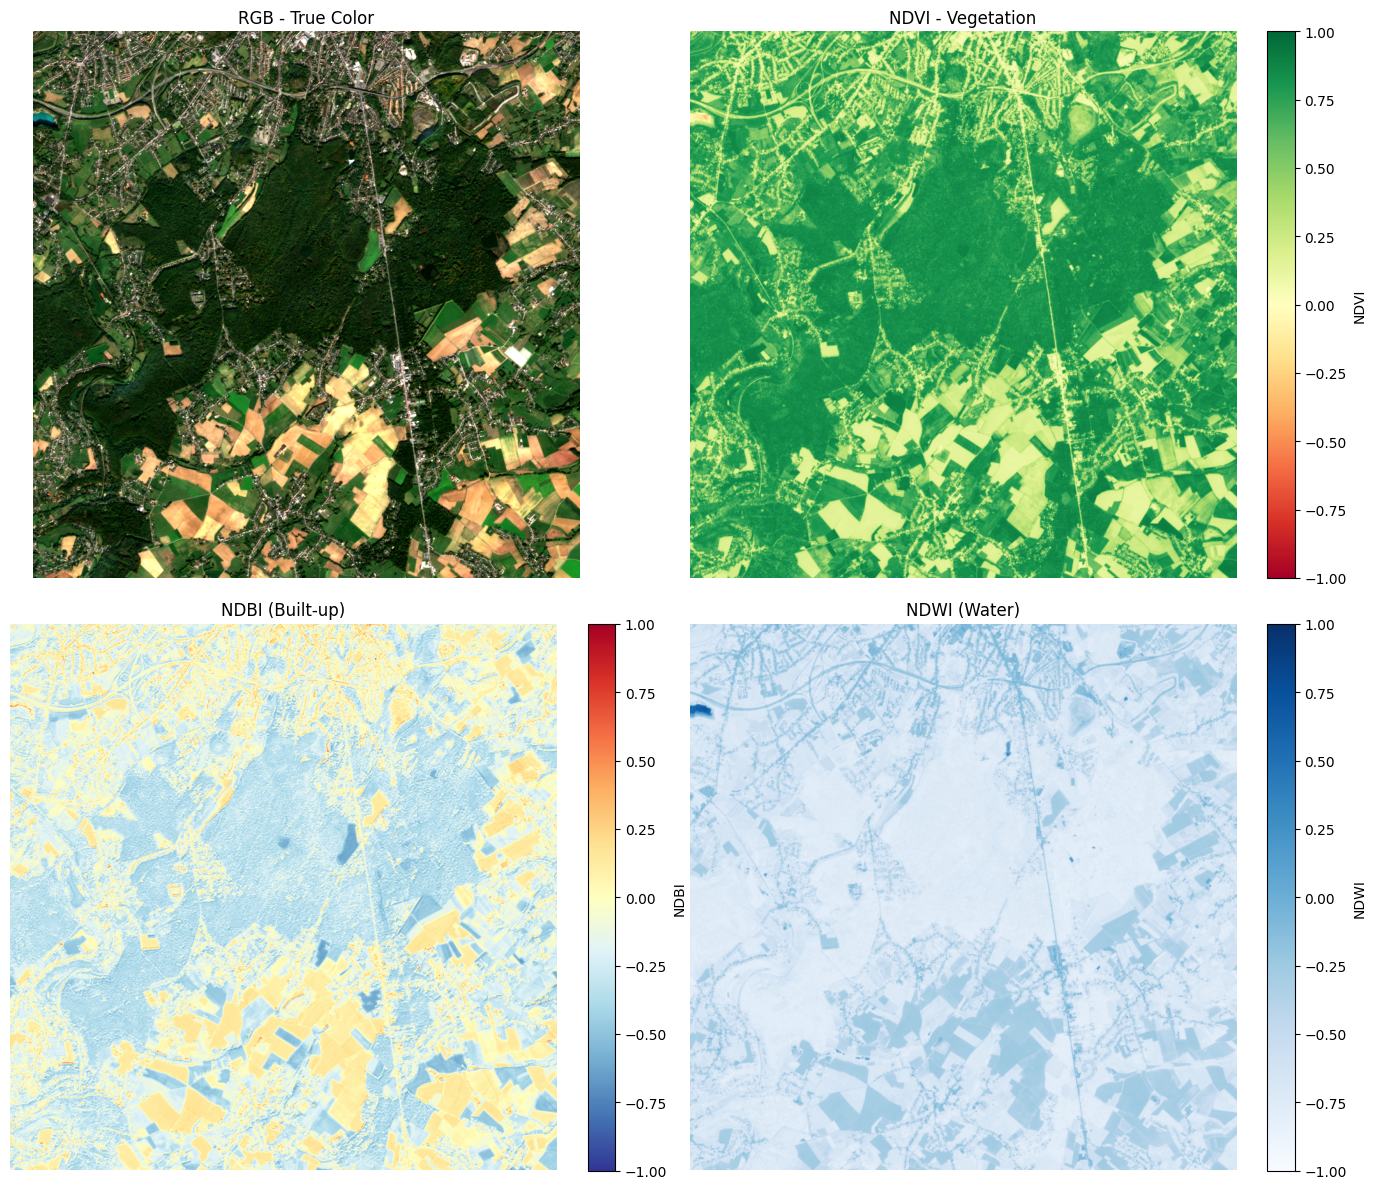

In [9]:
# Visualize the RGB image and computed indices
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot RGB image (True Color Composite)
# Normalize RGB values to 0-1 range for display
rgb = np.stack([red, green, blue], axis=-1)
# Apply percentile stretching for better visualization
p2, p98 = np.percentile(rgb, (2, 98))
rgb_stretched = np.clip((rgb - p2) / (p98 - p2), 0, 1)

axes[0, 0].imshow(rgb_stretched)
axes[0, 0].set_title('RGB - True Color')
axes[0, 0].axis('off')

# Plot NDVI
im1 = axes[0, 1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0, 1].set_title('NDVI - Vegetation')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], label='NDVI', fraction=0.046)

# Plot NDBI
im2 = axes[1, 0].imshow(ndbi, cmap='RdYlBu_r', vmin=-1, vmax=1)
axes[1, 0].set_title('NDBI (Built-up)')
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], label='NDBI', fraction=0.046)

# Plot NDWI
im3 = axes[1, 1].imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
axes[1, 1].set_title('NDWI (Water)')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1], label='NDWI', fraction=0.046)

plt.tight_layout()
plt.show()



# Step 3: Create class masks (vegetation, built-up, water)
This step thresholds NDVI, NDBI, and NDWI to create per-class binary masks and makes them mutually exclusive.

- Vegetation: NDVI > 0.3
- Built-up: NDBI > 0.2
- Water: NDWI > 0.2

A small morphological clean-up removes speckles, and a simple priority resolves overlaps: Water > Vegetation > Built-up.

Pixels: total=732736
  Vegetation: 84.0% → 84.6% (620062 px)
  Built-up:   17.4% → 10.5% (76962 px)
  Water:      0.1% → 0.1% (396 px)


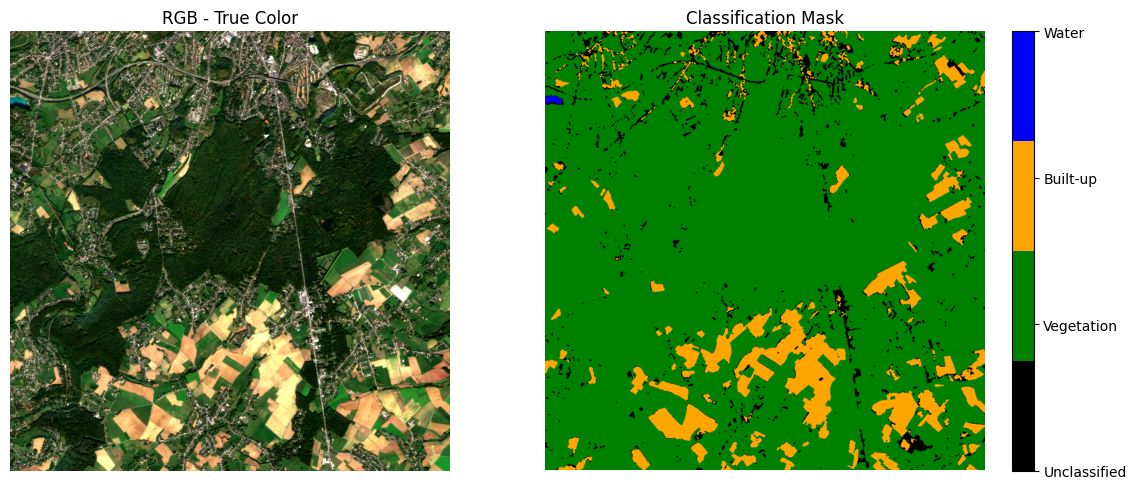

In [10]:
# Create binary masks for vegetation, built-up, and water
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.morphology import remove_small_objects, disk, binary_opening, binary_closing

# Thresholds 
ndvi_thr = 0.3   # vegetation
ndbi_thr = 0.05   # built-up
ndwi_thr = 0.2   # water

def compute_masks(ndvi, ndbi, ndwi, ndvi_thr=ndvi_thr, ndbi_thr=ndbi_thr, ndwi_thr=ndwi_thr):
    # Calculate dimensions to ensure all arrays match
    min_rows = min(ndvi.shape[0], ndbi.shape[0], ndwi.shape[0])
    min_cols = min(ndvi.shape[1], ndbi.shape[1], ndwi.shape[1])
    
    # Crop all arrays to match dimensions
    ndvi_crop = ndvi[:min_rows, :min_cols]
    ndbi_crop = ndbi[:min_rows, :min_cols]
    ndwi_crop = ndwi[:min_rows, :min_cols]

    # Initial thresholded masks
    veg0 = (ndvi_crop > ndvi_thr)
    built0 = (ndbi_crop > ndbi_thr)
    water0 = (ndwi_crop > ndwi_thr)

    # Simple cleaning to remove small speckles and smooth edges
    def clean(mask: np.ndarray, min_size: int = 50, radius: int = 1) -> np.ndarray:
        mask = mask.astype(bool)
        mask = remove_small_objects(mask, min_size=min_size)
        if radius and radius > 0:
            se = disk(radius)
            mask = binary_opening(mask, se)
            mask = binary_closing(mask, se)
        return mask

    # Enforce mutual exclusivity with priority: Water > Vegetation > Built-up
    water_mask = clean(water0, radius=1)
    veg_mask = clean(veg0 & ~water_mask, radius=1)
    built_mask = clean(built0 & ~water_mask & ~veg_mask, radius=1)
    return veg_mask, built_mask, water_mask, ndvi_crop, veg0, built0, water0
[veg_mask, built_mask, water_mask, ndvi_crop, veg0, built0, water0] = compute_masks(ndvi, ndbi, ndwi)

# Get mask dimensions for visualization
min_rows, min_cols = ndvi_crop.shape

# Report coverage
total_px = int(ndvi_crop.size)
get_pct = lambda m: 100.0 * float(m.sum()) / total_px if total_px > 0 else 0.0
print(f"Pixels: total={total_px}")
print(f"  Vegetation: {get_pct(veg0):.1f}% → {get_pct(veg_mask):.1f}% ({veg_mask.sum()} px)")
print(f"  Built-up:   {get_pct(built0):.1f}% → {get_pct(built_mask):.1f}% ({built_mask.sum()} px)")
print(f"  Water:      {get_pct(water0):.1f}% → {get_pct(water_mask):.1f}% ({water_mask.sum()} px)")

# Visualization: RGB + combined classification mask
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RGB (crop to match mask dimensions)
rgb_crop = np.stack([red[:min_rows, :min_cols], green[:min_rows, :min_cols], blue[:min_rows, :min_cols]], axis=-1)
p2, p98 = np.percentile(rgb_crop, (2, 98))
rgb_stretched = np.clip((rgb_crop - p2) / (p98 - p2), 0, 1)
axes[0].imshow(rgb_stretched)
axes[0].set_title('RGB - True Color')
axes[0].axis('off')

# Combined classification mask: 0=unclassified, 1=vegetation, 2=built-up, 3=water
classification = np.zeros_like(veg_mask, dtype=np.uint8)
classification[veg_mask] = 1
classification[built_mask] = 2
classification[water_mask] = 3

# Custom colormap: black, green, orange, blue
from matplotlib.colors import ListedColormap
colors = ['black', 'green', 'orange', 'blue']
cmap = ListedColormap(colors)

im = axes[1].imshow(classification, cmap=cmap, vmin=0, vmax=3)
axes[1].set_title('Classification Mask')
axes[1].axis('off')

# Add colorbar with labels
cbar = plt.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3], fraction=0.046)
cbar.ax.set_yticklabels(['Unclassified', 'Vegetation', 'Built-up', 'Water'])

plt.tight_layout()
plt.show()

In [11]:
# Sort products by date
no_cloud_products_sorted = sorted(no_cloud_products, key=lambda p: p.properties['date'])

print(f"Processing {len(no_cloud_products_sorted)} products sorted by date\n")

# Track previous masks for change detection
prev_classification = None
prev_date = None
use_verbose = False

# Store change visualizations for carousel
change_plots = []

for idx, product in enumerate(no_cloud_products_sorted):
    product_name = product.title
    product_date = product.properties['date'].split('T')[0]
    
    print(f"\n{'='*60}")
    print(f"[{idx+1}/{len(no_cloud_products_sorted)}] {product_name}")
    print(f"Date: {product_date}")
    print('='*60)
    
    try:
        # Load and process product
        [blue, green, red, nir, swir] = load_product_files(product_name, verbose=use_verbose)
        [ndvi, ndbi, ndwi] = compute_indices(red, nir, swir, green, verbose=use_verbose)
        [veg_mask, built_mask, water_mask, ndvi_crop, veg0, built0, water0] = compute_masks(ndvi, ndbi, ndwi)
        
        # Create classification map
        classification = np.zeros_like(veg_mask, dtype=np.uint8)
        classification[veg_mask] = 1
        classification[built_mask] = 2
        classification[water_mask] = 3
        
        # Calculate coverage
        total_px = int(classification.size)
        get_pct = lambda val: 100.0 * float((classification == val).sum()) / total_px
        
        print(f"\nCoverage:")
        print(f"  Vegetation: {get_pct(1):.1f}%")
        print(f"  Built-up:   {get_pct(2):.1f}%")
        print(f"  Water:      {get_pct(3):.1f}%")
        print(f"  Unclassified: {get_pct(0):.1f}%")
        
        # Detect changes from previous date
        if prev_classification is not None:
            # Calculate pixel-wise changes
            changed_pixels = (classification != prev_classification).sum()
            change_pct = 100.0 * changed_pixels / total_px
            
            if change_pct > 0.5:  # Report if more than 0.5% changed
                print(f"\n⚠️ CHANGE DETECTED from {prev_date} to {product_date}:")
                print(f"   {change_pct:.1f}% of pixels changed ({changed_pixels:,} pixels)")
                
                # Detailed change breakdown
                change_summary = []
                for from_class in range(4):
                    for to_class in range(4):
                        if from_class != to_class:
                            mask = (prev_classification == from_class) & (classification == to_class)
                            count = mask.sum()
                            if count > 0:
                                class_names = ['Unclassified', 'Vegetation', 'Built-up', 'Water']
                                pct = 100.0 * count / total_px
                                print(f"   {class_names[from_class]} → {class_names[to_class]}: {pct:.2f}% ({count:,} px)")
                                change_summary.append(f"{class_names[from_class]} → {class_names[to_class]}: {pct:.2f}%")
                
                # Create change visualization
                change_mask = (classification != prev_classification).astype(np.uint8)
                
                # Store plot data
                change_plots.append({
                    'prev_date': prev_date,
                    'curr_date': product_date,
                    'prev_class': prev_classification.copy(),
                    'curr_class': classification.copy(),
                    'change_mask': change_mask,
                    'change_pct': change_pct,
                    'summary': change_summary
                })
            else:
                print(f"\nNo significant change from {prev_date} (only {change_pct:.2f}% changed)")
        
        # Store for next iteration
        prev_classification = classification.copy()
        prev_date = product_date
        
    except Exception as e:
        print(f"✗ Error processing product: {e}")
        continue

print(f"\n{'='*60}")
print("Change detection complete!")
print(f"Found {len(change_plots)} significant changes")
print('='*60)

Processing 11 products sorted by date


[1/11] S2A_20170327T105021_31UFR_TOC_V200
Date: 2017-03-27
All required bands found:
⚠️ Window starts outside image bounds!
✗ Error processing product: 
⚠️ Coordinates appear outside image

[2/11] S2B_20170829T105019_31UFR_TOC_V200
Date: 2017-08-29
All required bands found:
⚠️ Window starts outside image bounds!
✗ Error processing product: 
⚠️ Coordinates appear outside image

[3/11] S2B_20171015T104009_31UER_TOC_V200
Date: 2017-10-15
All required bands found:
Window size in pixels: 857 x 857

Coverage:
  Vegetation: 87.6%
  Built-up:   8.2%
  Water:      0.0%
  Unclassified: 4.1%

[4/11] S2A_20180418T104021_31UER_TOC_V200
Date: 2018-04-18
All required bands found:
Window size in pixels: 857 x 857

Coverage:
  Vegetation: 87.6%
  Built-up:   8.2%
  Water:      0.0%
  Unclassified: 4.1%

[4/11] S2A_20180418T104021_31UER_TOC_V200
Date: 2018-04-18
All required bands found:
Window size in pixels: 857 x 857

Coverage:
  Vegetation: 87.0%
  Built-up:  

In [12]:
# Visualize changes in a carousel
if len(change_plots) > 0:
    from matplotlib.colors import ListedColormap
    import ipywidgets as widgets
    from IPython.display import display
    
    # Custom colormap for classification
    colors = ['black', 'green', 'orange', 'blue']
    cmap_class = ListedColormap(colors)
    
    # Change colormap: gray for no change, red for change
    cmap_change = ListedColormap(['lightgray', 'red'])
    
    def plot_change(index):
        """Plot a specific change comparison."""
        if index < 0 or index >= len(change_plots):
            return
        
        data = change_plots[index]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Previous classification
        im1 = axes[0].imshow(data['prev_class'], cmap=cmap_class, vmin=0, vmax=3)
        axes[0].set_title(f'Classification: {data["prev_date"]}')
        axes[0].axis('off')
        cbar1 = plt.colorbar(im1, ax=axes[0], ticks=[0, 1, 2, 3], fraction=0.046)
        cbar1.ax.set_yticklabels(['Unclassified', 'Vegetation', 'Built-up', 'Water'])
        
        # Current classification
        im2 = axes[1].imshow(data['curr_class'], cmap=cmap_class, vmin=0, vmax=3)
        axes[1].set_title(f'Classification: {data["curr_date"]}')
        axes[1].axis('off')
        cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0, 1, 2, 3], fraction=0.046)
        cbar2.ax.set_yticklabels(['Unclassified', 'Vegetation', 'Built-up', 'Water'])
        
        # Change mask
        im3 = axes[2].imshow(data['change_mask'], cmap=cmap_change, vmin=0, vmax=1)
        axes[2].set_title(f'Changes: {data["change_pct"]:.1f}% of pixels')
        axes[2].axis('off')
        cbar3 = plt.colorbar(im3, ax=axes[2], ticks=[0, 1], fraction=0.046)
        cbar3.ax.set_yticklabels(['No change', 'Changed'])
        
        # Add change summary as text
        if data['summary']:
            summary_text = '\n'.join(data['summary'][:5])  # Show top 5 changes
            fig.text(0.5, 0.02, summary_text, ha='center', fontsize=9, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        plt.tight_layout()
        plt.show()
    
    # Create interactive carousel
    print(f"\n🎠 Change Visualization Carousel ({len(change_plots)} changes detected)")
    print("Use the slider to navigate through detected changes:\n")
    
    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(change_plots) - 1,
        step=1,
        description=f'Change:',
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='d'
    )
    
    # Interactive widget
    widgets.interactive(plot_change, index=slider)
    
    # Display the interactive widget
    display(widgets.interactive(plot_change, index=slider))

else:
    print("No significant changes detected to visualize.")


🎠 Change Visualization Carousel (7 changes detected)
Use the slider to navigate through detected changes:



interactive(children=(IntSlider(value=0, continuous_update=False, description='Change:', max=6), Output()), _d…